<a id="top"></a>
# Chapter 8 — Magnetic, EXAFS and diffuse scattering

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 8 of 10

[◀ 7 Corrections: resolution, Q-damping and nano-size](RMCProfile_07_Corrections.ipynb) · [Contents of the book](README.md) · [9 Analysing configurations ▶](RMCProfile_09_Analysing_Configurations.ipynb)

**In this chapter**

- [§32 Beyond the pair distribution](#sec-32)
- [§33 Magnetic scattering](#sec-33)
- [§34 Three-dimensional diffuse scattering](#sec-34)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 20}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 8")
t_chapter_start = time.time()

rmcprofile-skill 0.5.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 8


<a id="sec-32"></a>

## 32. Beyond the pair distribution

Three data types in RMCProfile are not pair distribution functions and this book's engine
does not compute them. This chapter is documentary where it must be and live where the
package allows: EXAFS runs here on the shipped SnO exercise; magnetic scattering and
three-dimensional diffuse scattering are described from the manual with their keyword
blocks, so that a reader who has such data knows what the program expects.

**EXAFS** (manual §4.7, `EXAFS ::` block; Krayzman et al. 2009). The extended X-ray
absorption fine structure $\chi(k)$ of one absorbing element is a sum over its scattering
paths; RMCProfile computes it from the configuration with FEFF-style amplitudes and phases
supplied in the exercise's `.1sc1`/`.2sc3`… files and fits it in $k$ or in $r$ space.
Keywords: `FILENAME`, `TYPE(S)_OF_ABSORBING_ATOMS`, `START_POINT_(k_space)`,
`END_POINT_(k_space)`, `FIT_space`, `START_POINT_(r_space)`, `END_POINT_(r_space)`,
`R_SPACING`, `K_POWER`, `ENERGY_OFFSET`, `WEIGHT` — one block per edge. The absorber and
scatterer lists (`absorlist.dat`, `scattlist.dat`) and the path amplitudes come from the
`Prep/` step of the exercise, not from RMCProfile.

2 EXAFS blocks; absorbers: ['2', '1'] | fit spaces: ['r', 'r']


rc 0, 18 s | chi2 rows: {'m_accepted': 0, 'm_generated': 1, 'm_tested': 0, 'chi2': 0.001422, 'Expt_1': 0.001371, 'EXAFS_1': 0.0233, 'EXAFS_2': 0.0246}
EXAFS outputs: ['Nb-EXAFS-1_Q_OUTPUT.csv', 'Nb-EXAFS-1_R_OUTPUT.csv', 'Sr-EXAFS-2_Q_OUTPUT.csv', 'Sr-EXAFS-2_R_OUTPUT.csv']


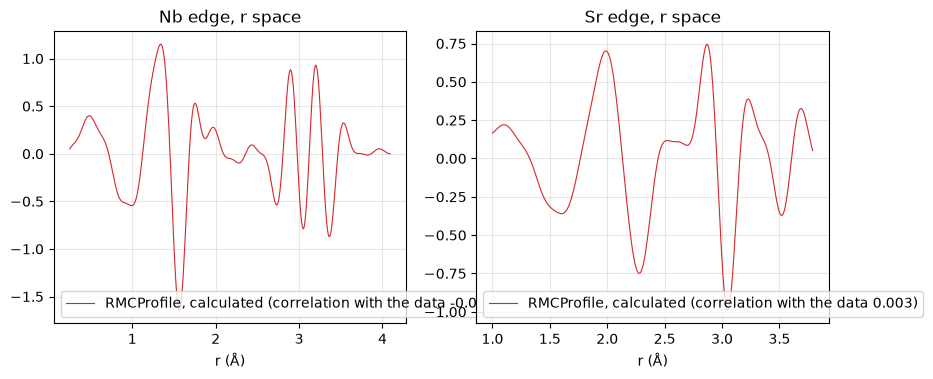

[PASS] RMCProfile evaluated both EXAFS edges (EXAFS_1 and EXAFS_2 chi2 rows)
[PASS] it wrote a k-space and an r-space CSV per edge


In [2]:
if not skip_without_package("the EXAFS run"):
    work = os.path.join(WORK, "exafs_ex_7")
    ua.stage_exercise(PKG, "ex_7", work)
    stem = ua.EXERCISES["ex_7"].stem
    d = rt.read_dat(os.path.join(work, stem + ".dat"))
    exafs = [b for b in d.blocks if b.name == "EXAFS"]
    print(f"{len(exafs)} EXAFS blocks; absorbers:", [b.get("TYPE(S)_OF_ABSORBING_ATOMS") for b in exafs],
          "| fit spaces:", [b.get("FIT_space") or b.get("Fit_space") for b in exafs])
    d.scalars["TIME_LIMIT"] = "0.0 MINUTES"
    d.scalars["SAVE_PERIOD"] = "0.0 MINUTES"
    d.write(os.path.join(work, stem + ".dat"))
    t0 = time.time()
    res = rt.run_rmcprofile(stem, work, PKG, timeout_min=6)
    print(f"rc {res.returncode}, {time.time() - t0:.0f} s | chi2 rows: {res.final_chi2}")
    outs = sorted(o for o in res.outputs if "EXAFS" in o and o.endswith(".csv"))
    print("EXAFS outputs:", outs)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for ax, name in zip(axes, [o for o in outs if "_R_" in o]):
        x, calc, expt = rt.read_csv_pair(os.path.join(work, name))
        ax.plot(x, calc, "C3", lw=0.8, label=f"RMCProfile, calculated (correlation with the data {np.corrcoef(calc, expt)[0, 1]:.3f})")
        ax.set_title(name.split("-")[0] + " edge, r space"); ax.set_xlabel("r (Å)"); ax.legend()
    show(fig)
    caption("The two EXAFS edges of the package's SnO exercise (Nb and Sr absorbers) in r space: "
            "RMCProfile's calculation for the shipped starting configuration, evaluated with no "
            "moves. The exercise's measured χ(r) is not reproduced here (it belongs to the package); "
            "the legend gives the calculation's correlation with it.")
    check("RMCProfile evaluated both EXAFS edges (EXAFS_1 and EXAFS_2 chi2 rows)", res.returncode == 0 and {"EXAFS_1", "EXAFS_2"} <= set(res.final_chi2))
    check("it wrote a k-space and an r-space CSV per edge", len(outs) == 4)

<a id="sec-33"></a>

## 33. Magnetic scattering

Magnetic neutron scattering adds to the nuclear pair distribution a spin–spin term with a
magnetic form factor, and RMCProfile refines spin orientations together with positions
(manual §4.8; Paddison & Goodwin 2012 for the spin-RMC idea). The `MAGNETISM ::` block
carries `FORM_FACTOR` (the ion's magnetic form factor coefficients), `MAGNETISM_FILE_STEM`,
`MAGNETIC_ATOMS` (which types carry a moment), `MAX_SPIN_MOVEMENT` and `SPIN_MOVE_RATE`
(how far and how often a spin rotates instead of an atom moving); the spins live in a
companion file to the `.rmc6f`. The package ships no magnetic exercise, so this section has
no run — a reader with a magnetic data set has the block above and the checker, which
accepts the keywords as scalars of the block without judging their values.

<a id="sec-34"></a>

## 34. Three-dimensional diffuse scattering

Single-crystal diffuse scattering fits (manual §4.9, `DIFFUSE_SCATTERING3D ::`; Welberry &
Weber 2016 review the method) compare a calculated reciprocal-space volume with a measured
one; the configuration must be a `SUPERCELL_DIMENSIONS`-declared supercell so that the
average amplitude can be computed (that keyword's manual entry says so). The `.hkl`-style
reflection list of the Bragg block is not used — the data are a volume — and the fit is
costly per move. As for magnetism, the package ships no exercise and this book runs none.

Where this leaves the book: every real-space and reciprocal-space pair-distribution data
type is reproduced (chapters 1–4, 7), the X-ray route is reproduced in scale and partly in
shape (chapter 5), Bragg profiles and EXAFS are run on the shipped exercises with the
program's own files (chapters 5, 8), and magnetic and diffuse-scattering fits are described
from the manual only. Chapter 9 turns to what one does with a refined box.

In [3]:
# the keyword inventory of this chapter, as the checker sees it: block names RMCProfile knows
known = ["EXAFS", "MAGNETISM", "DIFFUSE_SCATTERING3D", "BRAGG", "NEUTRON_REAL_SPACE_DATA",
         "NEUTRON_RECIPROCAL_SPACE_DATA", "XRAY_REAL_SPACE_DATA", "XRAY_RECIPROCAL_SPACE_DATA"]
print("data-block names this book covers:", ", ".join(known))
check("chapter 8 lists the three data types it cannot reproduce with rmclite", {"EXAFS", "MAGNETISM", "DIFFUSE_SCATTERING3D"} <= set(known))

data-block names this book covers: EXAFS, MAGNETISM, DIFFUSE_SCATTERING3D, BRAGG, NEUTRON_REAL_SPACE_DATA, NEUTRON_RECIPROCAL_SPACE_DATA, XRAY_REAL_SPACE_DATA, XRAY_RECIPROCAL_SPACE_DATA
[PASS] chapter 8 lists the three data types it cannot reproduce with rmclite


True

### Exercises for chapter 8

**8.1** In the SnO exercise's `.dat` file, which `K_POWER` weights the EXAFS data, and what
does a higher power do to the fit's sensitivity at large $k$?

**8.2** The run above wrote a k-space and an r-space output per edge. Read the k-space one
and check that its k range agrees with the `START_POINT_(k_space)` / `END_POINT_(k_space)`
values of the block — are they point indices, as in the PDF blocks, or k values?

In [4]:
if not skip_without_package("the exercises"):
    # 8.1 — read it off the staged file rather than quoting it
    kp = [b.get("K_POWER") for b in exafs]
    print("K_POWER per edge:", kp, "— chi(k) is multiplied by k^n, so a higher n amplifies the weak high-k oscillations")
    check("8.1 both EXAFS blocks declare a K_POWER", all(v is not None for v in kp))
    # 8.2 — the k-space output against the block's declared range
    k1, kc, ke = rt.read_csv_pair(os.path.join(work, [o for o in outs if "_Q_" in o][0]))
    b0 = exafs[0]
    k_lo, k_hi = float(b0.get("START_POINT_(k_space)")), float(b0.get("END_POINT_(k_space)"))
    print(f"k-space output: {len(k1)} points, k = {k1.min():.3f}–{k1.max():.3f} Å⁻¹; block says START {k_lo}, END {k_hi}")
    print("the values are k in Å⁻¹, not point indices — unlike START_POINT / END_POINT of the PDF blocks")
    check("8.2 the k-space output lies within the declared k range", k1.min() >= k_lo - 0.05 and k1.max() <= k_hi + 0.05,
          f"{k1.min():.2f}–{k1.max():.2f} vs {k_lo}–{k_hi}")

K_POWER per edge: ['2', '2'] — chi(k) is multiplied by k^n, so a higher n amplifies the weak high-k oscillations
[PASS] 8.1 both EXAFS blocks declare a K_POWER
k-space output: 199 points, k = 3.300–13.200 Å⁻¹; block says START 3.3, END 13.2
the values are k in Å⁻¹, not point indices — unlike START_POINT / END_POINT of the PDF blocks
[PASS] 8.2 the k-space output lies within the declared k range — 3.30–13.20 vs 3.3–13.2


In [5]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 8 — checks passed : {_CHECKS['pass']}")
print(f"chapter 8 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 8 — checks passed : 5
chapter 8 — checks failed : 0
wall time                 : 19 s
Every quantitative claim in this notebook was verified in this run.
